In [13]:
import sys
sys.path.insert(0, '..')

from utils.preprocessing import preprocess_data, load_and_preprocess_data
from utils.evaluation import (
    load_and_evaluate_cnnlstm_model,
)
import joblib
import pandas as pd
from sklearn.metrics import classification_report

In [8]:
df_cicids2017 = load_and_preprocess_data("../data/CICIDS2017/wednesday_labeled.tsv")
df_ciciot2023 = load_and_preprocess_data("../data/CICIoT2023/ciciot2023_labeled_conn.tsv")

In [16]:
df = df_cicids2017.copy()
for col in [
    "duration",
    "orig_bytes",
    "resp_bytes",
    "missed_bytes",
    "orig_pkts",
    "orig_ip_bytes",
    "resp_pkts",
    "resp_ip_bytes",
]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0.0)
duration_safe = df["duration"].replace(0, 1e-6)


df["orig_pkt_rate"] = df["orig_pkts"] / duration_safe
df["orig_byte_rate"] = df["orig_bytes"] / duration_safe
df["pkt_asymmetry"] = df["orig_pkts"] / (df["resp_pkts"] + 1.0)
df["byte_asymmetry"] = df["orig_bytes"] / (df["resp_bytes"] + 1.0)

In [17]:
label_column = "label"

df_cicids2017 = df[df["label"].isin(["DOS_HTTP_FLOOD"] + ["BENIGN"])]
X_cicids = df_cicids2017.drop(columns=[label_column])
y_cicids = df_cicids2017[label_column]

X_ciciot = df_ciciot2023.drop(columns=[label_column])
y_ciciot = df_ciciot2023[label_column]

print("CICIDS test shape:", X_cicids.shape)
print("CICIoT test shape:", X_ciciot.shape)

CICIDS test shape: (481829, 26)
CICIoT test shape: (1850844, 22)


Evaluation for CICIoT2023-trained CNNLSTM tested on CICIDS2017:

=== CICIoT2023-trained CNNLSTM tested on CICIDS2017 Classification Report ===

                precision    recall  f1-score   support

        BENIGN     0.8458    0.9508    0.8953    327060
DOS_HTTP_FLOOD     0.8592    0.6338    0.7295    154769

      accuracy                         0.8490    481829
     macro avg     0.8525    0.7923    0.8124    481829
  weighted avg     0.8501    0.8490    0.8420    481829


=== Per-Label Accuracy ===

BENIGN: 0.9508
DOS_HTTP_FLOOD: 0.6338


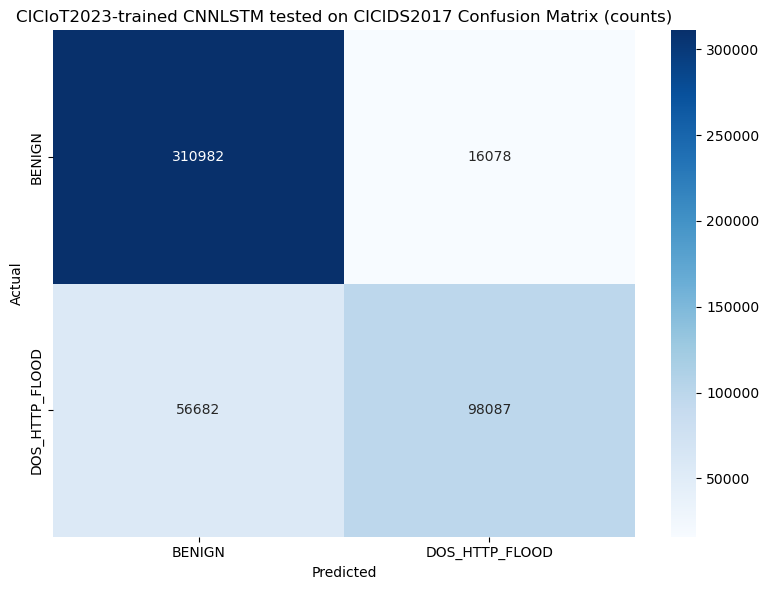

{'predictions': array(['DOS_HTTP_FLOOD', 'BENIGN', 'BENIGN', ..., 'BENIGN', 'BENIGN',
        'DOS_HTTP_FLOOD'], shape=(481829,), dtype=object),
 'confusion_matrix': array([[310982,  16078],
        [ 56682,  98087]]),
 'accuracy': np.float64(0.848992069800697),
 'classification_report': {'BENIGN': {'precision': 0.8458320640584882,
   'recall': 0.9508408243135816,
   'f1-score': 0.8952677610101277,
   'support': 327060.0},
  'DOS_HTTP_FLOOD': {'precision': 0.8591687469890071,
   'recall': 0.6337638674411542,
   'f1-score': 0.7294503484126217,
   'support': 154769.0},
  'accuracy': 0.848992069800697,
  'macro avg': {'precision': 0.8525004055237477,
   'recall': 0.7923023458773679,
   'f1-score': 0.8123590547113747,
   'support': 481829.0},
  'weighted avg': {'precision': 0.8501159595493647,
   'recall': 0.848992069800697,
   'f1-score': 0.8420053066325303,
   'support': 481829.0}}}

In [18]:
# Load CICIoT2023 model and evaluate on CICIDS2017
load_and_evaluate_cnnlstm_model(
    joblib_path="models/cnnlstm_property_ciciot2023.joblib",
    X=X_cicids,
    y_true=y_cicids,
    model_name="CICIoT2023-trained CNNLSTM tested on CICIDS2017"
)

Evaluation for CICIDS2017-trained CNNLSTM tested on CICIoT2023:

=== CICIDS2017-trained CNNLSTM tested on CICIoT2023 Classification Report ===

                precision    recall  f1-score   support

        BENIGN     0.2013    0.9692    0.3334    342255
DOS_HTTP_FLOOD     0.9480    0.1276    0.2250   1508589

      accuracy                         0.2833   1850844
     macro avg     0.5747    0.5484    0.2792   1850844
  weighted avg     0.8099    0.2833    0.2450   1850844


=== Per-Label Accuracy ===

BENIGN: 0.9692
DOS_HTTP_FLOOD: 0.1276


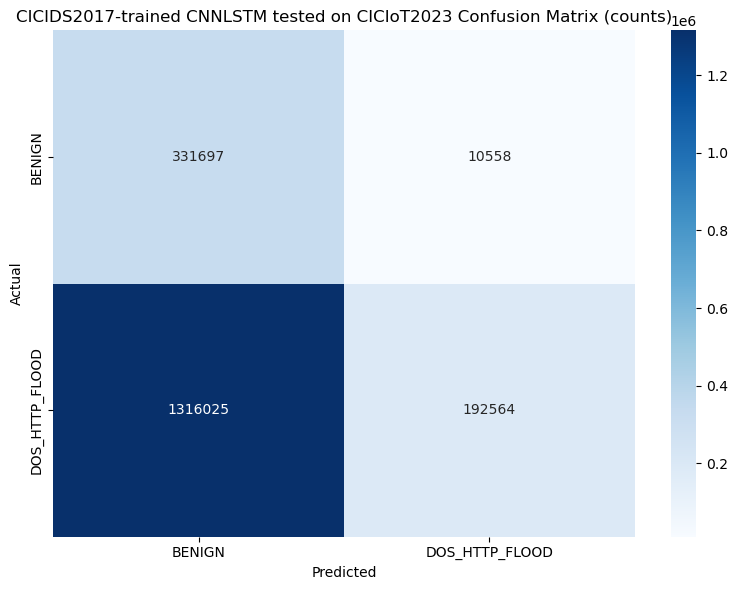

Cross-dataset evaluation saved to: ..\experiments\20260405_210240_2props\cross_eval_on_ciciot2023.json


WindowsPath('../experiments/20260405_210240_2props/cross_eval_on_ciciot2023.json')

In [ ]:
# Load CICIDS2017 model and evaluate on CICIoT2023
load_and_evaluate_cnnlstm_model(
    joblib_path="models/cnnlstm_property_cicids2017.joblib",
    X=X_ciciot,
    y_true=y_ciciot,
    model_name="CICIDS2017-trained CNNLSTM tested on CICIoT2023"
)